# Clustering Iris dataset using KMeans

In [13]:
from sklearn.datasets import load_iris
dataset = load_iris()

In [14]:
from sklearn.cluster import KMeans

# Use KMeans to cluster data into 3 clusters
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
labels = kmeans.fit_predict(dataset.data)

# Print distance from each point to its centroid, known as _inertia_
print(kmeans.inertia_)

78.8556658259773


In [15]:
# Create a cross-tabulation table of the cluster labels and iris target values
import pandas as pd

species = [dataset.target_names[i] for i in dataset.target]
print(species)

['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicolor', 'versicol

In [16]:
labels = kmeans.labels_

# check the predicted vs actual species
df = pd.DataFrame({'labels': labels, 'species': species})
print(df)

     labels    species
0         1     setosa
1         1     setosa
2         1     setosa
3         1     setosa
4         1     setosa
..      ...        ...
145       2  virginica
146       0  virginica
147       2  virginica
148       2  virginica
149       0  virginica

[150 rows x 2 columns]


In [17]:
ct = pd.crosstab(df['labels'], df['species'])

print(ct)

species  setosa  versicolor  virginica
labels                                
0             0          47         14
1            50           0          0
2             0           3         36


In [18]:
# Generate numpy array with new test data
import numpy as np

testSet = np.array([[5.0, 3.9, 1.3, 0.25], [4.3, 3.0, 1.1, 0.1]])

print(testSet.shape)

(2, 4)


## Visualize the clusters, centroids and the samples

In [19]:
# prepare the additional data for visualisation

predictions = kmeans.predict(testSet)
print(predictions)


[1 1]


In [20]:
centroids = kmeans.cluster_centers_

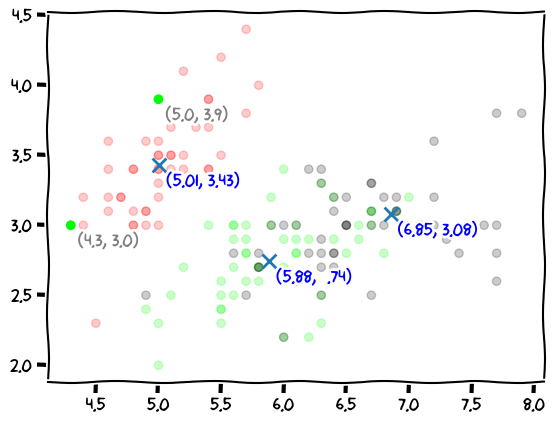

In [34]:
from matplotlib import pyplot as plt

# prepare a colormap for the clusters
colormap = np.array(['red', 'lime', 'black'])

plt.xkcd()
plt.scatter(dataset.data[:,0], dataset.data[:,1], c=colormap[dataset.target], alpha=0.2)
plt.scatter(testSet[:,0], testSet[:,1], c=colormap[predictions])
plt.scatter(centroids[:,0], centroids[:,1], marker='x', s=100)

for x,y in zip(testSet[:,0], testSet[:,1]):
    plt.annotate('(%.1f, %.1f)' % (x,y), xy=(x,y), xytext=(5, -15), textcoords='offset points', color='grey')

for x,y in zip(centroids[:,0], centroids[:,1]):
    plt.annotate('(%.2f, %.2f)' % (x,y), xy=(x,y), xytext=(5, -15), textcoords='offset points', color='blue')

plt.show()

## Measuring the quality of clustering (via inertia)


A good cluster is one that is:

    * tight (samples in the same cluster are close to each other)
    * low inertia (samples in the same cluster are not spread out)

Find the "ellbow" in the inertia plot to find the optimal number of clusters

In [22]:
plotRange = range(1, 10)
inertias = []

for k in plotRange:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans.fit(dataset.data)

    inertias.append(kmeans.inertia_)

print(inertias)

[681.3706, 152.34795176035792, 78.8556658259773, 57.228473214285714, 49.827740558292284, 42.421545753097476, 34.420191786283894, 30.064593073593073, 28.715856536394465]


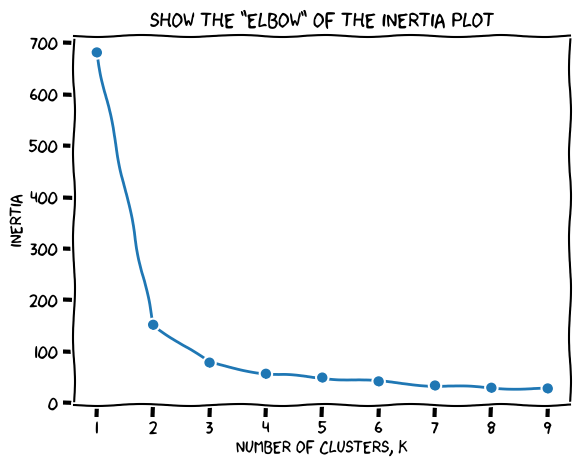

In [23]:
plt.title('Show the "Elbow" of the inertia plot')
plt.plot(plotRange, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(plotRange)
plt.show()